#sckit-fuzzyのインストール

In [1]:
pip install -U scikit-fuzzy

     |████████████████████████████████| 993 kB 4.2 MB/s 
  Created wheel for scikit-fuzzy: filename=scikit_fuzzy-0.4.2-py3-none-any.whl size=894089 sha256=6ddf9838991ec8a9534bca58f2bf0f67e701c6ae946b606a3df122e532215837
  Stored in directory: /root/.cache/pip/wheels/d5/74/fc/38588a3d2e3f34f74588e6daa3aa5b0a322bd6f9420a707131
Successfully built scikit-fuzzy


#日本語用ライブラリのインストール

In [2]:
pip install japanize_matplotlib

     |████████████████████████████████| 4.1 MB 4.1 MB/s 
  Created wheel for japanize-matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120274 sha256=df0c9f0ce864123580bd134477c9c79111786654778e45f7296555f265d2031f
  Stored in directory: /root/.cache/pip/wheels/83/97/6b/e9e0cde099cc40f972b8dd23367308f7705ae06cd6d4714658
Successfully built japanize-matplotlib


#ライブラリのインポート

In [3]:
import numpy as np
import skfuzzy as fuzz
import matplotlib.pyplot as plt
import japanize_matplotlib
from IPython import display
import skfuzzy.control as ctrl

#メンバシップ関数の定義

In [4]:
#値の範囲（-1～1までの範囲としておく）
universe = np.linspace(-1, 1, 5)

#ファジーの入力（温度と湿度）と出力（出力）
temp = ctrl.Antecedent(universe, '温度')
humidity = ctrl.Antecedent(universe, '湿度')
power = ctrl.Consequent(universe, '出力')

#各メンバーシップ関数の名前
names = ['nb', 'ns', 'ze', 'ps', 'pb']

#メンバシップ関数の作成
temp.automf(names=names)
humidity.automf(names=names)
power.automf(names=names)

##メンバシップ関数の可視化

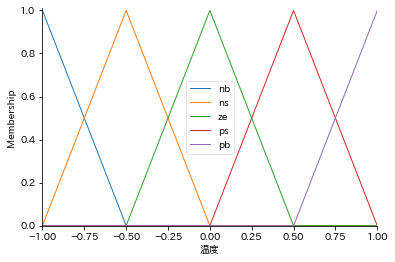

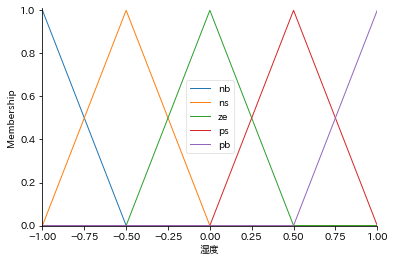

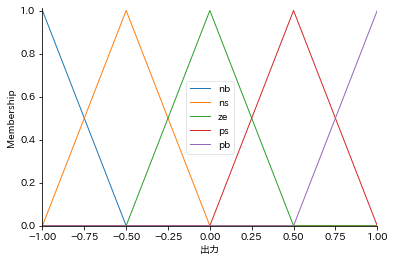

In [5]:
temp.view()
humidity.view()
power.view()

##ルールの定義

In [6]:
rule0 = ctrl.Rule(antecedent=((temp['nb'] & humidity['nb']) |
                              (temp['ns'] & humidity['nb']) |
                              (temp['nb'] & humidity['ns'])),
                  consequent=power['nb'], label='rule nb')

rule1 = ctrl.Rule(antecedent=((temp['nb'] & humidity['ze']) |
                              (temp['nb'] & humidity['ps']) |
                              (temp['ns'] & humidity['ns']) |
                              (temp['ns'] & humidity['ze']) |
                              (temp['ze'] & humidity['ns']) |
                              (temp['ze'] & humidity['nb']) |
                              (temp['ps'] & humidity['nb'])),
                  consequent=power['ns'], label='rule ns')

rule2 = ctrl.Rule(antecedent=((temp['nb'] & humidity['pb']) |
                              (temp['ns'] & humidity['ps']) |
                              (temp['ze'] & humidity['ze']) |
                              (temp['ps'] & humidity['ns']) |
                              (temp['pb'] & humidity['nb'])),
                  consequent=power['ze'], label='rule ze')

rule3 = ctrl.Rule(antecedent=((temp['ns'] & humidity['pb']) |
                              (temp['ze'] & humidity['pb']) |
                              (temp['ze'] & humidity['ps']) |
                              (temp['ps'] & humidity['ps']) |
                              (temp['ps'] & humidity['ze']) |
                              (temp['pb'] & humidity['ze']) |
                              (temp['pb'] & humidity['ns'])),
                  consequent=power['ps'], label='rule ps')

rule4 = ctrl.Rule(antecedent=((temp['ps'] & humidity['pb']) |
                              (temp['pb'] & humidity['pb']) |
                              (temp['pb'] & humidity['ps'])),
                  consequent=power['pb'], label='rule pb')

#設定

In [7]:
#ルールの設定
system = ctrl.ControlSystem(rules=[rule0, rule1, rule2, rule3, rule4])
#シミュレーションの設定
sim = ctrl.ControlSystemSimulation(system, flush_after_run=21 * 21 + 1)

#出力の決定（ファジー推論）


-0.06349206349206346


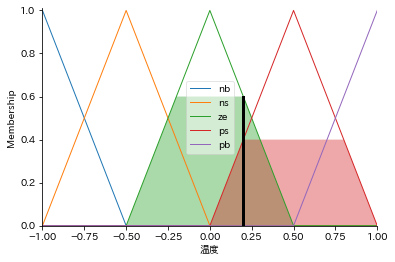

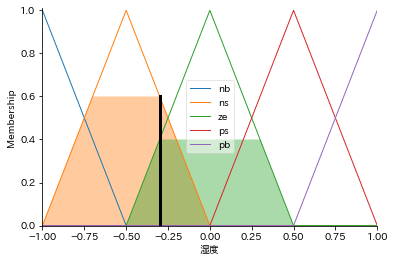

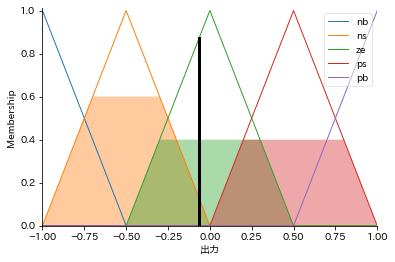

In [8]:
sim.input['温度'] = 0.2
sim.input['湿度'] = -0.3
sim.compute()
print(sim.output['出力'])
temp.view(sim=sim)
humidity.view(sim=sim)
power.view(sim=sim)

#温度と湿度の関係

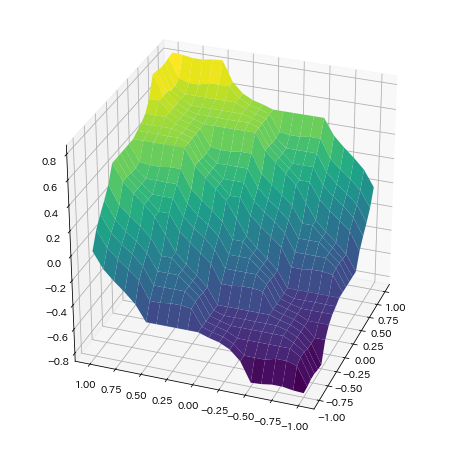

In [10]:
#表示範囲の設定
upsampled = np.linspace(-1, 1, 21)
x, y = np.meshgrid(upsampled, upsampled)
z = np.zeros_like(x)

# 表示範囲の各点の値を入力として出力を求める
for i in range(21):
    for j in range(21):
        sim.input['温度'] = x[i, j]
        sim.input['湿度'] = y[i, j]
        sim.compute()
        z[i, j] = sim.output['出力']

# 3次元プロット用ライブラリの読み込み
from mpl_toolkits.mplot3d import Axes3D 

#可視化
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(x, y, z, rstride=1, cstride=1, cmap='viridis',
                       linewidth=0.4, antialiased=True)
ax.view_init(30, 200)